In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error


In [ ]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df.head()


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday


In [ ]:
le = LabelEncoder()

df['weather_main'] = le.fit_transform(df['weather_main'])
df['holiday'] = le.fit_transform(df['holiday'])


In [ ]:
X = df[['hour', 'day', 'month', 'weekday', 'temperature', 'weather_main', 'holiday']]
y = df['traffic_volume']


KeyError: "['temperature'] not in index"

In [ ]:
print(df.columns)


Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'hour', 'day',
       'month', 'weekday'],
      dtype='object')


In [ ]:
X = df[['hour', 'day', 'month', 'weekday', 'temp', 'weather_main', 'holiday']]
y = df['traffic_volume']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['weather_main'] = le.fit_transform(df['weather_main'])
df['holiday'] = le.fit_transform(df['holiday'])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)


RandomForestRegressor()

In [ ]:
predictions = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)


Mean Absolute Error: 211.9452784980811


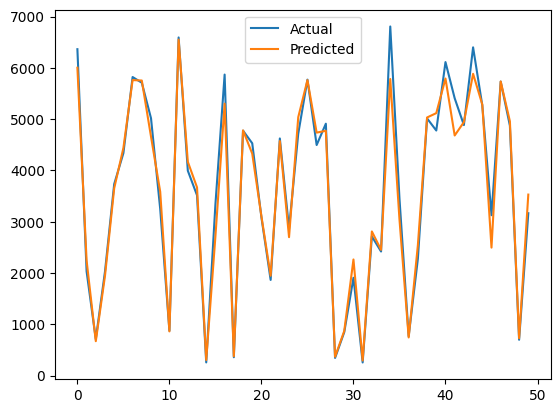

In [ ]:
plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(predictions[:50], label="Predicted")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)


MAE: 211.9452784980811
R2 Score: 0.964854012176605


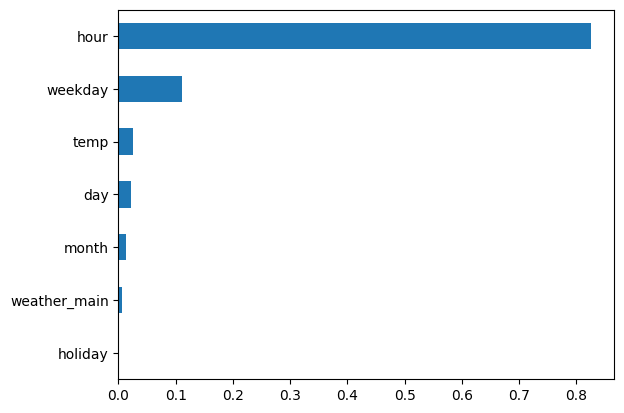

In [ ]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')
plt.show()
